In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('/content/customer_churn_data.csv')

In [4]:
data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [5]:
data.shape

(6418, 32)

In [6]:
data.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000
mean,47.070739,7.427859,17.342786,63.652867,2280.374858,1.924944,6.718604,748.703468,3033.871987
std,16.703633,4.621519,10.576391,31.188823,2268.049985,7.849083,24.722533,847.672844,2866.505426
min,18.000000,0.000000,1.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,33.000000,3.000000,8.000000,30.562500,395.725000,0.000000,0.000000,70.805000,603.742500
50%,46.000000,7.000000,16.000000,70.100000,1396.125000,0.000000,0.000000,407.475000,2108.635000
75%,60.000000,11.000000,27.000000,89.750000,3783.600000,0.000000,0.000000,1182.917500,4801.537500
max,85.000000,15.000000,36.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

**Customer Status Distribution**

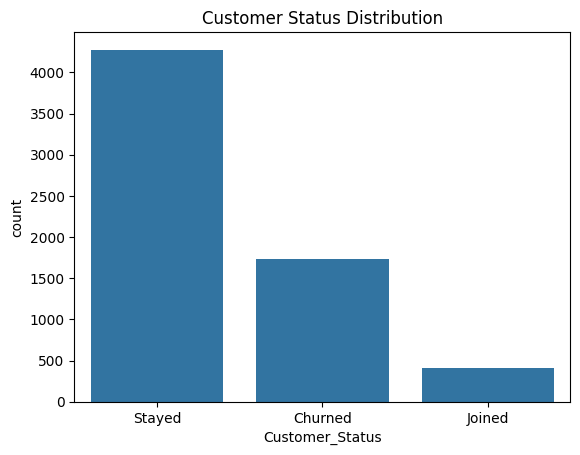

,proportion
Customer_Status,
Stayed,66.609536
Churned,26.986600
Joined,6.403864


In [15]:
sns.countplot(x='Customer_Status', data=data)
plt.title("Customer Status Distribution")
plt.show()

# Percentage
data['Customer_Status'].value_counts(normalize=True)*100

**Category for Customers Churn** *italicized text*

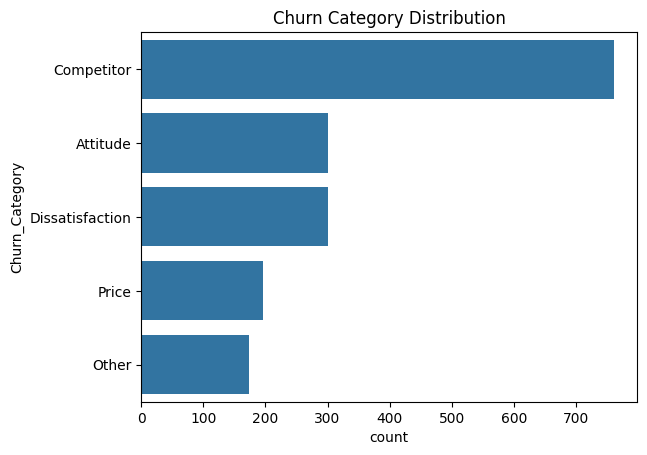

In [17]:
sns.countplot(y='Churn_Category', data=data,
              order=data['Churn_Category'].value_counts().index)
plt.title("Churn Category Distribution")
plt.show()

**Top Churn Reasons**

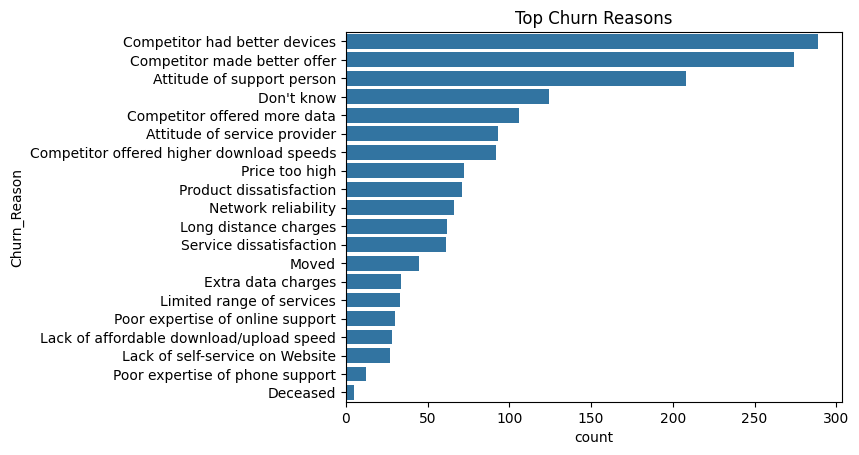

In [19]:

sns.countplot(y='Churn_Reason', data=data,
              order=data['Churn_Reason'].value_counts().index)
plt.title("Top Churn Reasons")
plt.show()

**Gender VS Churn relation**

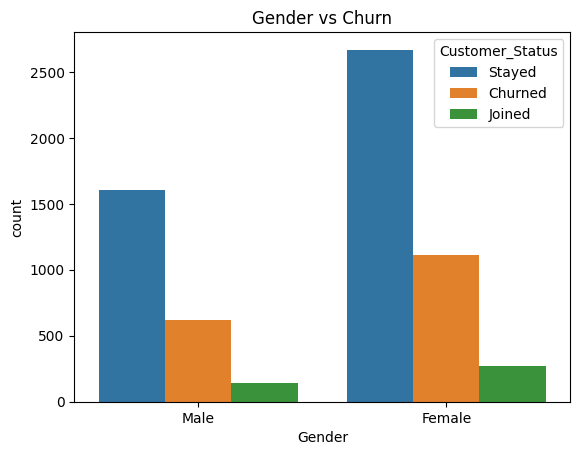

In [20]:
sns.countplot(x='Gender', hue='Customer_Status', data=data)
plt.title("Gender vs Churn")
plt.show()

**Age Distribution for Churn**

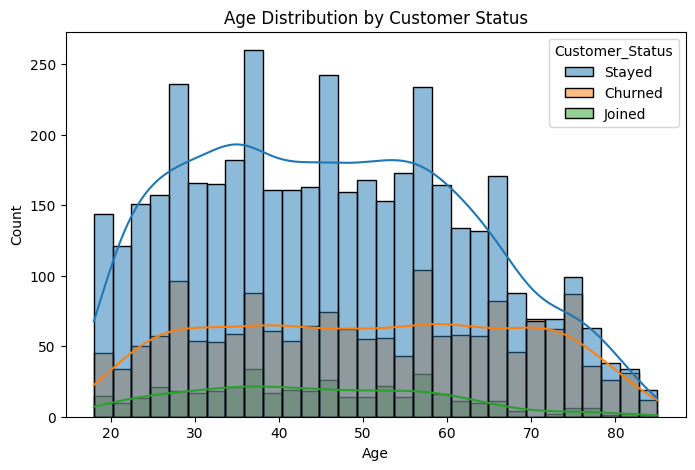

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(data=data, x='Age', hue='Customer_Status',
             bins=30, kde=True)
plt.title("Age Distribution by Customer Status")
plt.show()

**Married vs Churn**

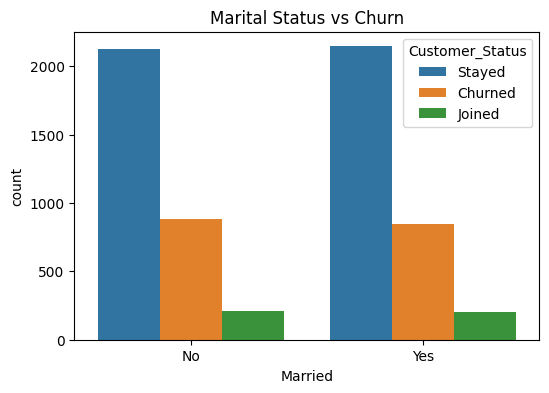

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Married', hue='Customer_Status', data=data)
plt.title("Marital Status vs Churn")
plt.show()

**Monthly Charge vs Churn**:The median amount paid by the churned customers were the highest, the mid line inside the box plot shows the median value

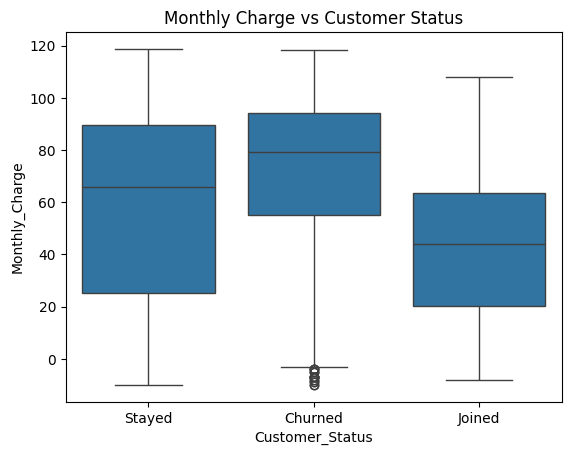

In [23]:
sns.boxplot(x='Customer_Status', y='Monthly_Charge', data=data)
plt.title("Monthly Charge vs Customer Status")
plt.show()

**Revenue and customers**

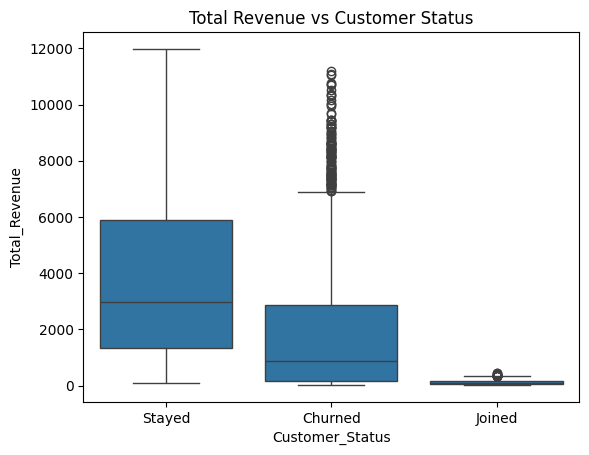

In [24]:
sns.boxplot(x='Customer_Status', y='Total_Revenue', data=data)
plt.title("Total Revenue vs Customer Status")
plt.show()

**Tenure vs Churn**

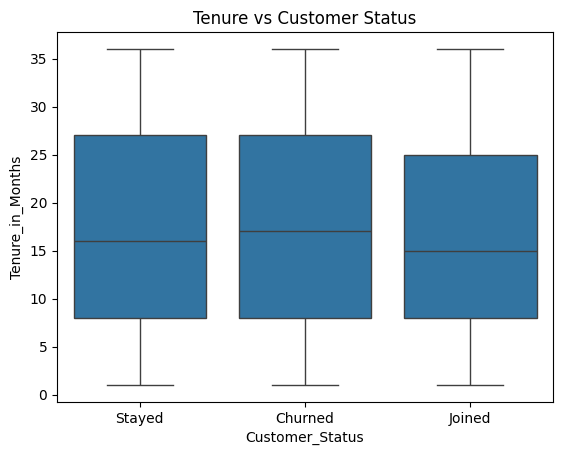

In [25]:
sns.boxplot(x='Customer_Status', y='Tenure_in_Months', data=data)
plt.title("Tenure vs Customer Status")
plt.show()

**Contract type and Churning relation**

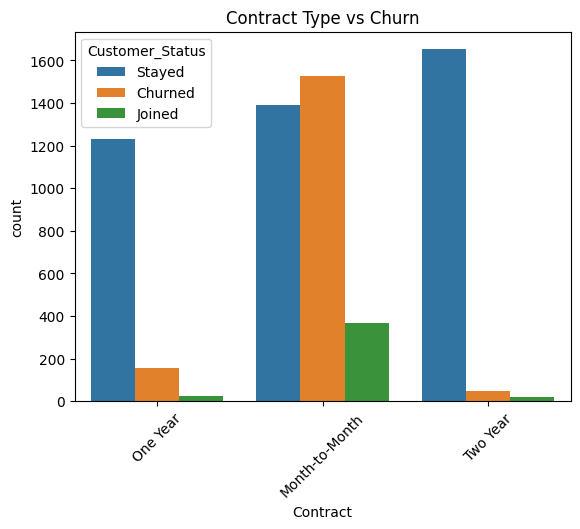

Customer_Status,Churned,Joined,Stayed
Contract,,,
Month-to-Month,46.530736,11.168594,42.300670
One Year,11.040340,1.698514,87.261146
Two Year,2.734148,1.163467,96.102385


In [26]:
sns.countplot(x='Contract', hue='Customer_Status', data=data)
plt.xticks(rotation=45)
plt.title("Contract Type vs Churn")
plt.show()

# Percentage view
pd.crosstab(data['Contract'],
            data['Customer_Status'],
            normalize='index')*100

**Payment Method Vs Churn**

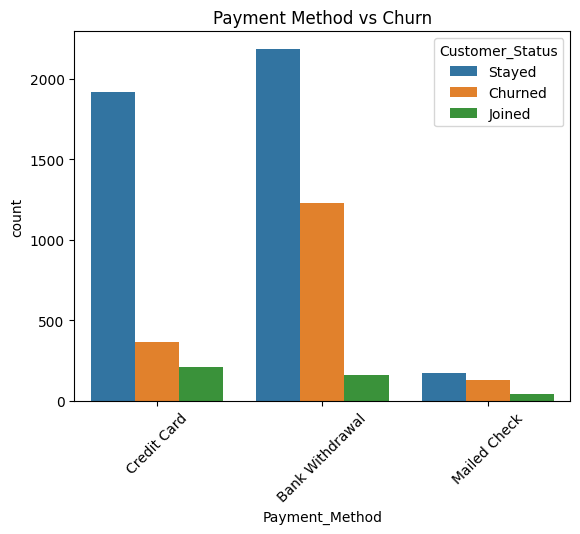

In [27]:
sns.countplot(x='Payment_Method', hue='Customer_Status', data=data)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

Internet Type vs Churn

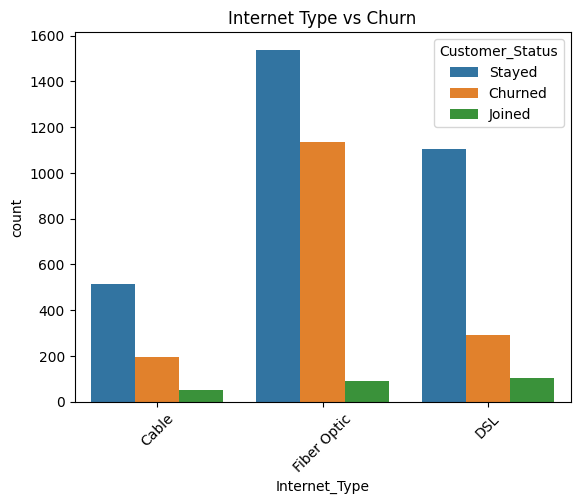

In [29]:
sns.countplot(x='Internet_Type', hue='Customer_Status', data=data)
plt.xticks(rotation=45)
plt.title("Internet Type vs Churn")
plt.show()

**Tenure Anlaysis**

In [30]:
data['Tenure_Group'] = pd.cut(
    data['Tenure_in_Months'],
    bins=[0,12,24,48,72],
    labels=['0-1yr','1-2yr','2-4yr','4-6yr']
)

pd.crosstab(data['Tenure_Group'],
            data['Customer_Status'],
            normalize='index')*100

Customer_Status,Churned,Joined,Stayed
Tenure_Group,,,
0-1yr,27.165817,6.781654,66.052528
1-2yr,26.351351,6.704782,66.943867
2-4yr,27.380340,5.609882,67.009779


**Correlation Heatmap**

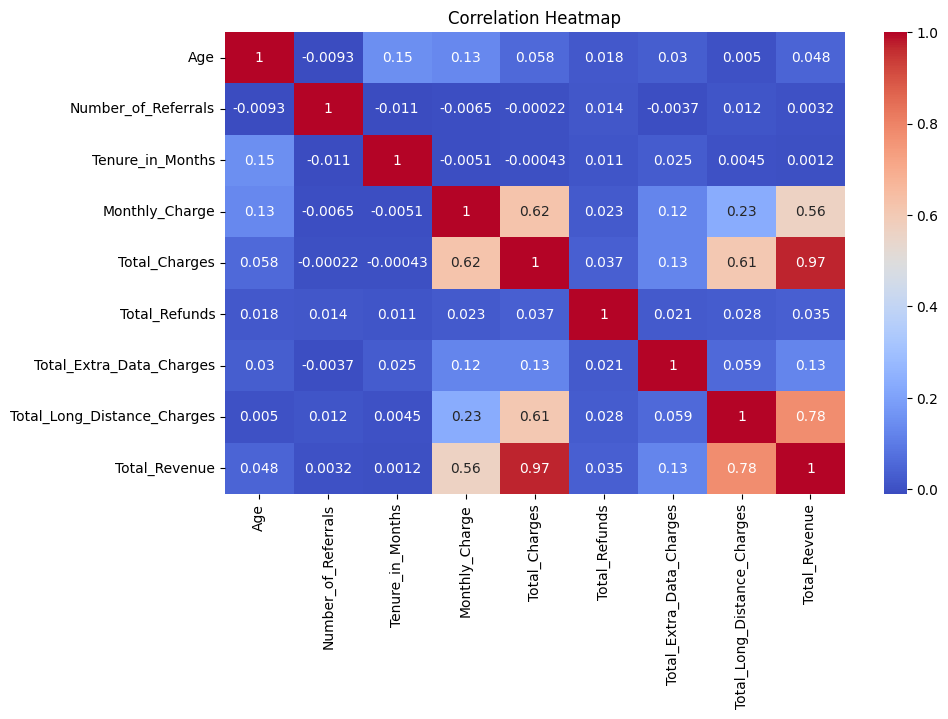

In [31]:
num_cols = data.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(10,6))
sns.heatmap(data[num_cols].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

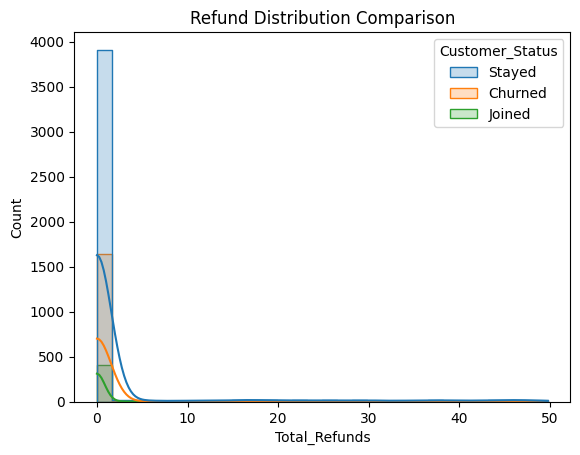

In [35]:
sns.histplot(data=data,
             x='Total_Refunds',
             hue='Customer_Status',
             bins=30,
             kde=True,
             element='step')
plt.title("Refund Distribution Comparison")
plt.show()

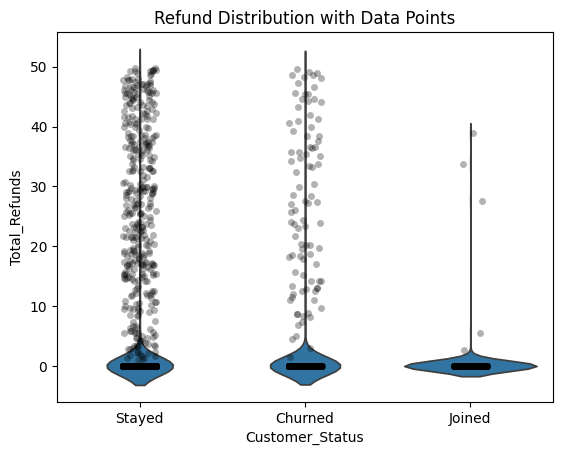

In [37]:
sns.violinplot(x='Customer_Status', y='Total_Refunds', data=data, inner=None)
sns.stripplot(x='Customer_Status', y='Total_Refunds', data=data,
              color='black', alpha=0.3)
plt.title("Refund Distribution with Data Points")
plt.show()